# Часть 1 — Анализ FastQC

С помощью [SRA Explorer](https://sra-explorer.info/) найдем файлы 4 ERRxxxxxx файла до 1000 Mb:



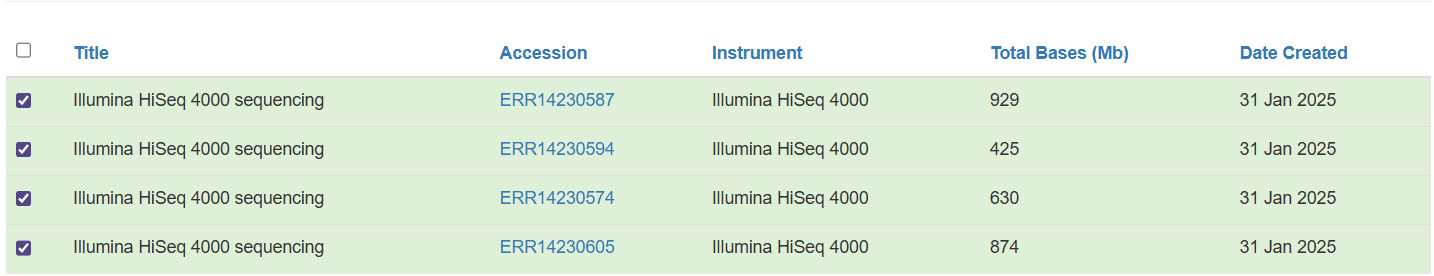

In [ ]:
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/094/ERR14230594/ERR14230594.fastq.gz
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/005/ERR14230605/ERR14230605.fastq.gz
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/074/ERR14230574/ERR14230574.fastq.gz
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/087/ERR14230587/ERR14230587.fastq.gz

Проведем fastqc на скачанных данных и агрегируем все отчеты в один с помощью multiqc:

Скрипт: [1_fastqc_raw.slurm](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/blob/main/hw5/scripts/1_fastqc_raw.slurm)

In [ ]:
#!/bin/bash
#SBATCH --job-name=fastqc_raw
#SBATCH --cpus-per-task=4
#SBATCH --mem=4gb
#SBATCH --time=00:30:00
#SBATCH --output=~/hw5_fastqc_trimming/fastqc_raw_%j.out
#SBATCH --partition=AMD9554-common

# Пути
DATA_DIR=~/hw5_fastqc_trimming/data/raw
OUTPUT_DIR=~/hw5_fastqc_trimming/results/fastqc_raw
MULTIQC_DIR=~/hw5_fastqc_trimming/results/multiqc

mkdir -p $OUTPUT_DIR $MULTIQC_DIR

cd $DATA_DIR

echo "=== FastQC для скачанных данных ==="
fastqc -t 4 *.fastq.gz -o $OUTPUT_DIR

echo "=== MultiQC ==="
multiqc $OUTPUT_DIR -o $MULTIQC_DIR -n multiqc_raw_report

echo "=== FastQC and MultiQC completed successfully! ==="


Результаты анализа на всех данных можно посмотреть в [multiqc_raw_report.html](https:/https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/blob/main/hw5/results/multiqc/multiqc_raw_report.html/)

# Часть 2 — Тримминг

Проанализиреум результаты отчета  MultiQC:

Status Checks: Status for each FastQC section showing whether results seem entirely normal (green), slightly abnormal (orange) or very unusual (red).

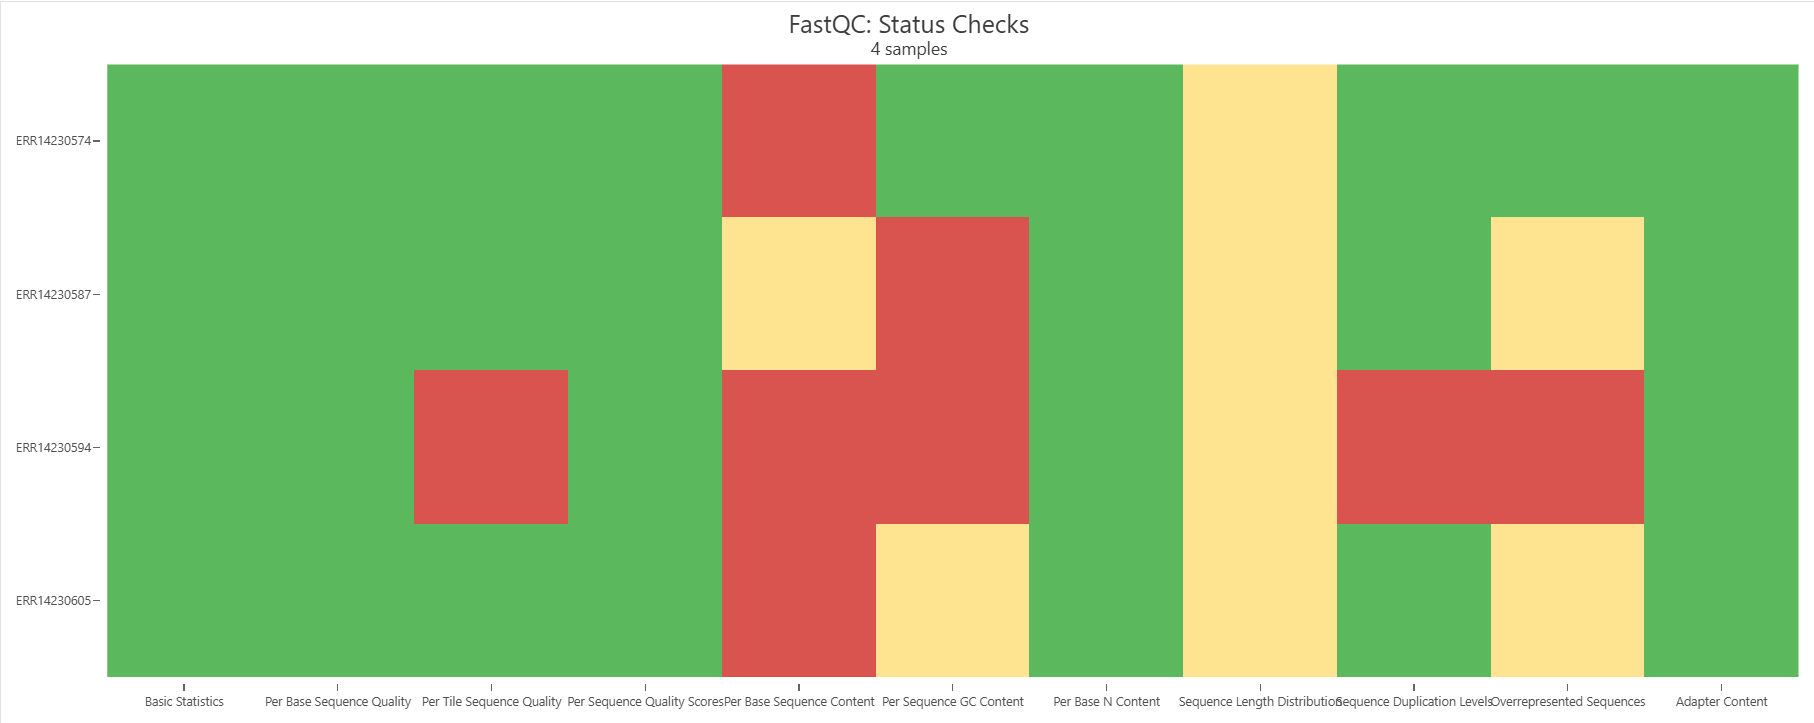

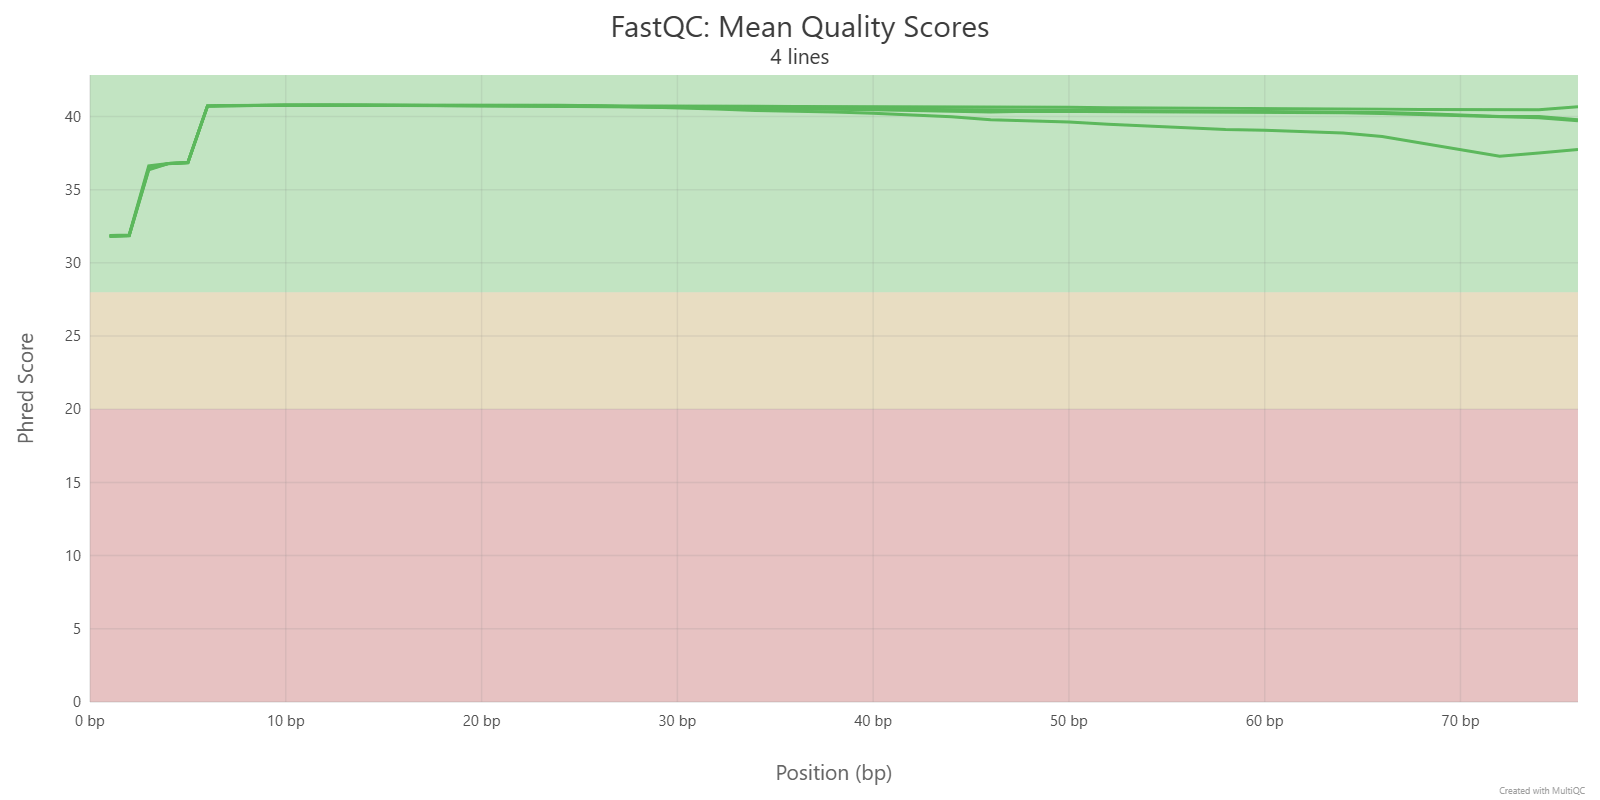

На протяжении всего рида качество сохраняется на высоком уровне (полностью в зеленой области). На концах рида (10-20 bp) качество немного падает, но также не выходит за границы зеленой зоны.

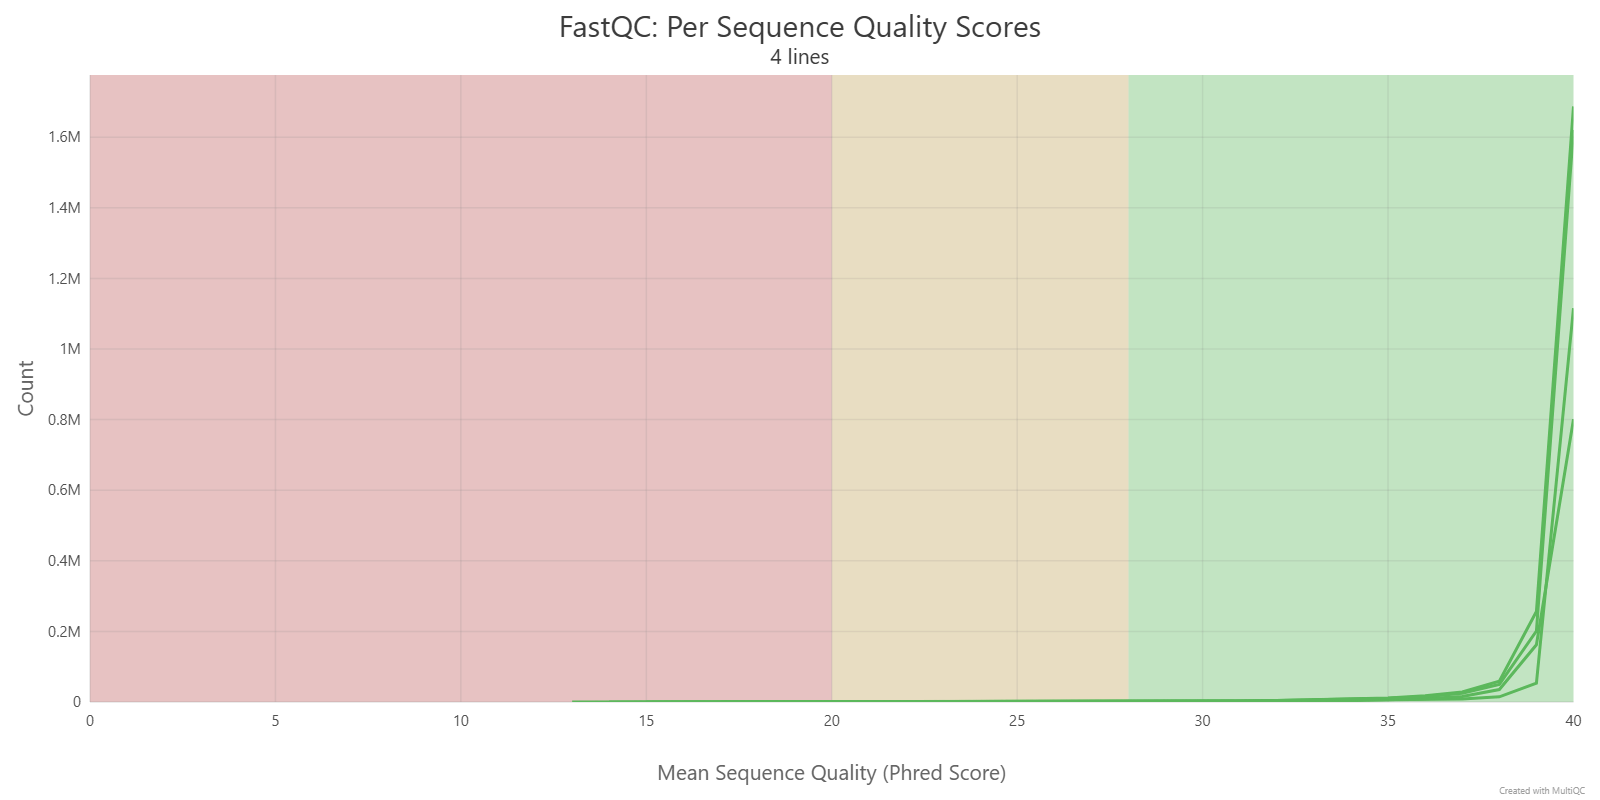

Большинство ридов имеют среднее качество 35-40 Phred. Но есть небольшой процент ридов с качеством 10-15 Phred.

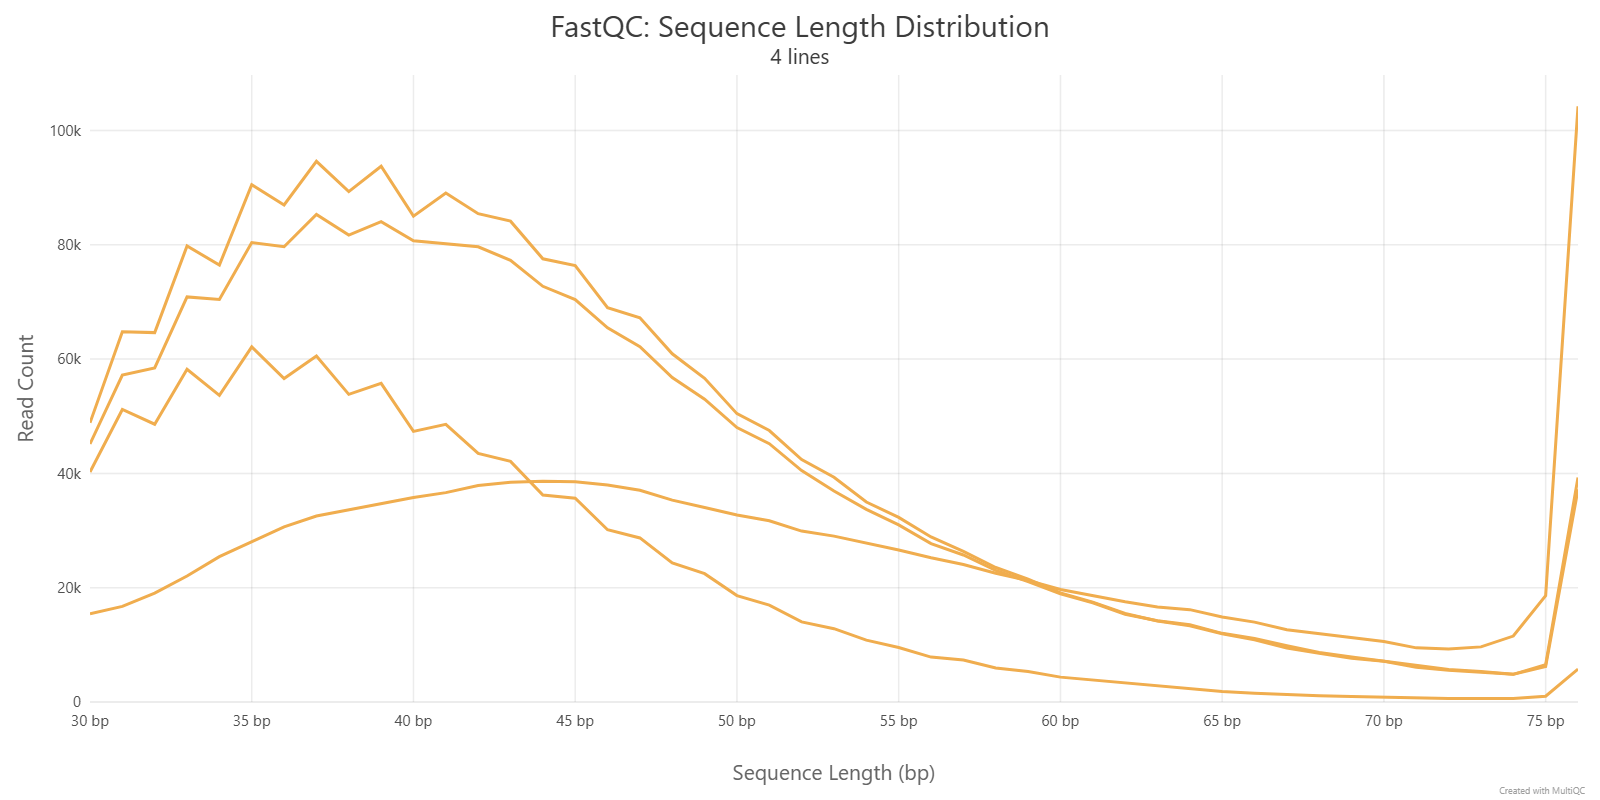

Большинство ридов длины >75 из, но также присутсвуют риды с меньшей длиной, в том числе менее 36 bp.

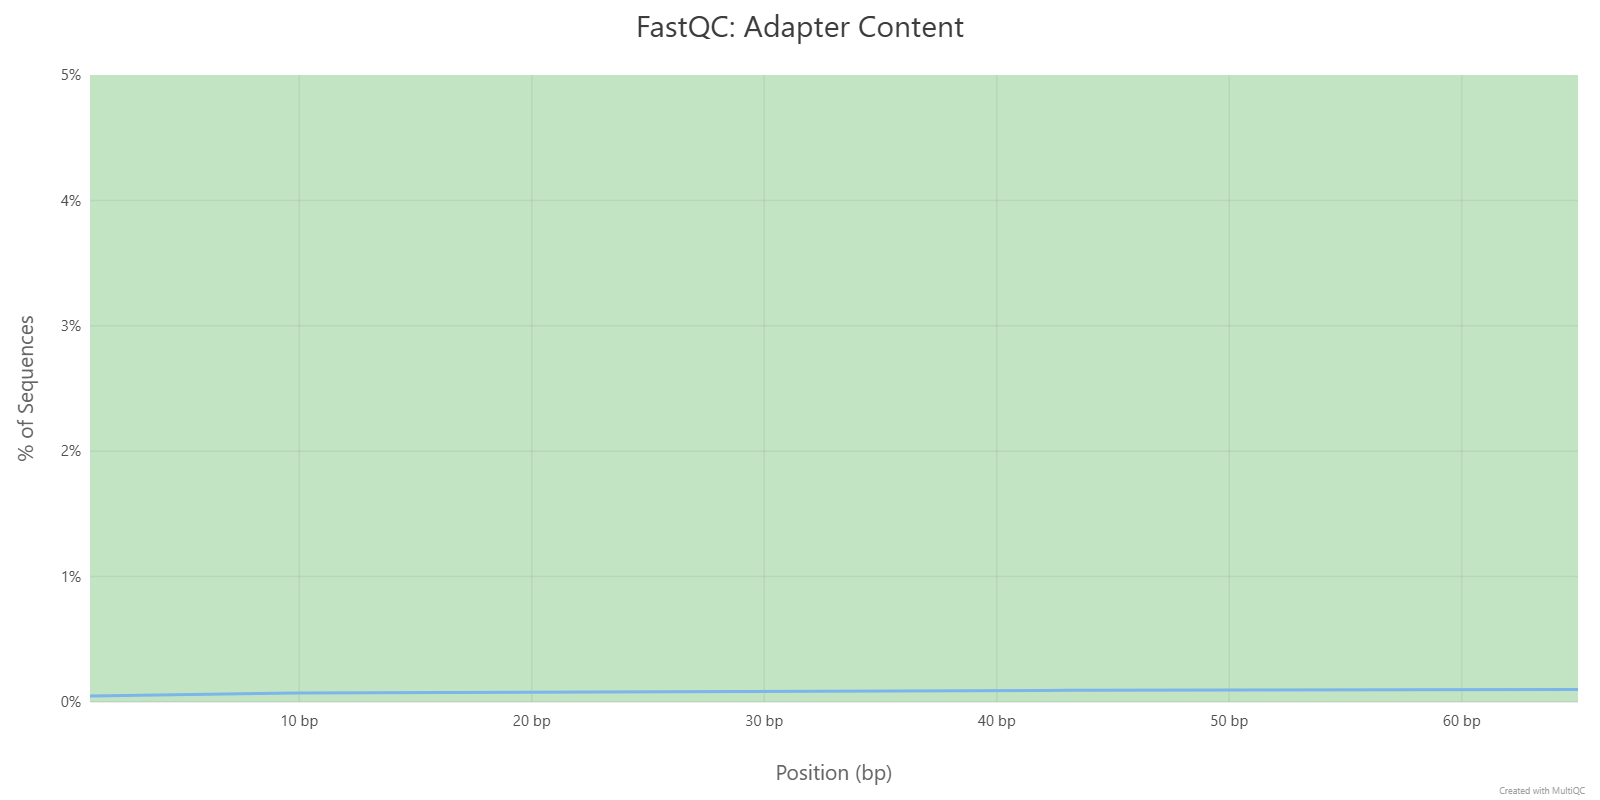

Адаптеры в данных практически отсутсвуют.

Данные уже хорошего качества, тем не менее проведем тримминг данных при помощи FastQC. Применим скрипт, который
- Обрежет адаптеры (auto-detection).
- Применит скользящее окно (5:20) для удаления плохих участков.
- Отбросит риды короче 36 п.н.
- Сохранит очищенные файлы (например, *_trimmed.fastq.gz).

Скрипт: [2_fastp.slurm](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/blob/main/hw5/scripts/2_fastp.slurm)


In [ ]:
#!/bin/bash
#SBATCH --job-name=fastp_trim
#SBATCH --cpus-per-task=4
#SBATCH --mem=4gb
#SBATCH --time=00:30:00
#SBATCH --output=~/hw5_fastqc_trimming/fastp_%j.out
#SBATCH --partition=AMD9554-common

# Пути
RAW_DIR=~/hw5_fastqc_trimming/data/raw
TRIMMED_DIR=~/hw5_fastqc_trimming/data/trimmed
REPORT_DIR=~/hw5_fastqc_trimming/results/multiqc

mkdir -p $TRIMMED_DIR $REPORT_DIR

cd $RAW_DIR

for file in *.fastq.gz; do
    filename=$(basename "$file" .fastq.gz)

    echo "=== Обработка: $filename ==="

    fastp \
        -i "$file" \
        -o "$TRIMMED_DIR/${filename}_trimmed.fastq.gz" \
        --detect_adapter_for_pe \
        --cut_front \
        --cut_tail \
        --cut_window_size 5 \
        --cut_mean_quality 20 \
        --length_required 36 \
        --html "$REPORT_DIR/${filename}_fastp.html"

    echo "$filename обработан"
done

echo ""
echo "=== Successfully! ==="


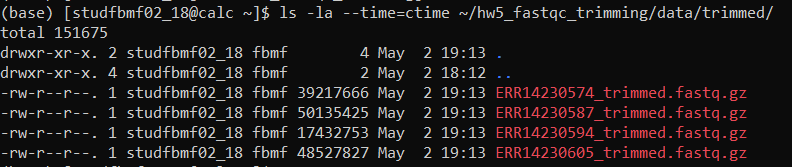

# Часть 3 — Контроль качества после тримминга

Повторно запустим FastQC, но уже на данных после тримминга и снова соберем отчет MultiQC.

Скрипт: [3_fastqc_trimmed.slurm](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/blob/main/hw5/scripts/3_fastqc_trimmed.slurm)

In [ ]:
#!/bin/bash
#SBATCH --job-name=fastqc_trimmed
#SBATCH --cpus-per-task=4
#SBATCH --mem=4gb
#SBATCH --time=00:30:00
#SBATCH --output=~/hw5_fastqc_trimming/fastqc_trimmed_%j.out
#SBATCH --partition=AMD9554-common

# Пути
DATA_DIR=~/hw5_fastqc_trimming/data/trimmed
OUTPUT_DIR=~/hw5_fastqc_trimming/results/fastqc_trimmed
MULTIQC_DIR=~/hw5_fastqc_trimming/results/multiqc

mkdir -p $OUTPUT_DIR $MULTIQC_DIR

cd $DATA_DIR

echo "=== FastQC ==="
fastqc -t 4 *.fastq.gz -o $OUTPUT_DIR

echo "=== MultiQC ==="
multiqc $OUTPUT_DIR -o $MULTIQC_DIR -n multiqc_trimmed_report

echo "=== Successfully! ==="


Результаты анализа можно посмотреть в [multiqc_trimmed_report.html](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/blob/main/hw5/results/multiqc/multiqc_trimmed_report.html).

Сравним результаты, полученные на исходных данных и данных после тримминга

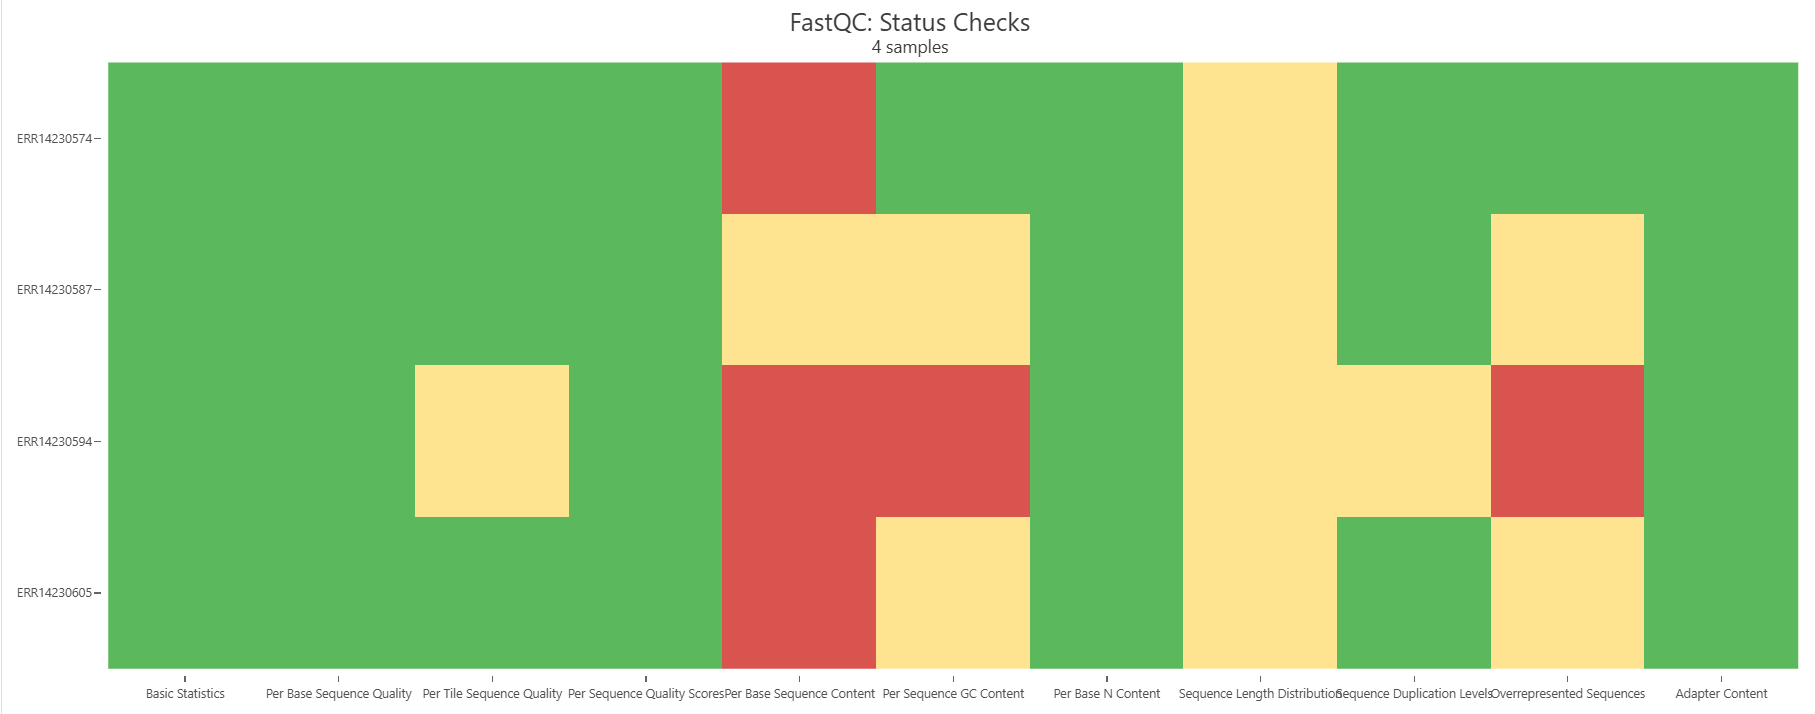

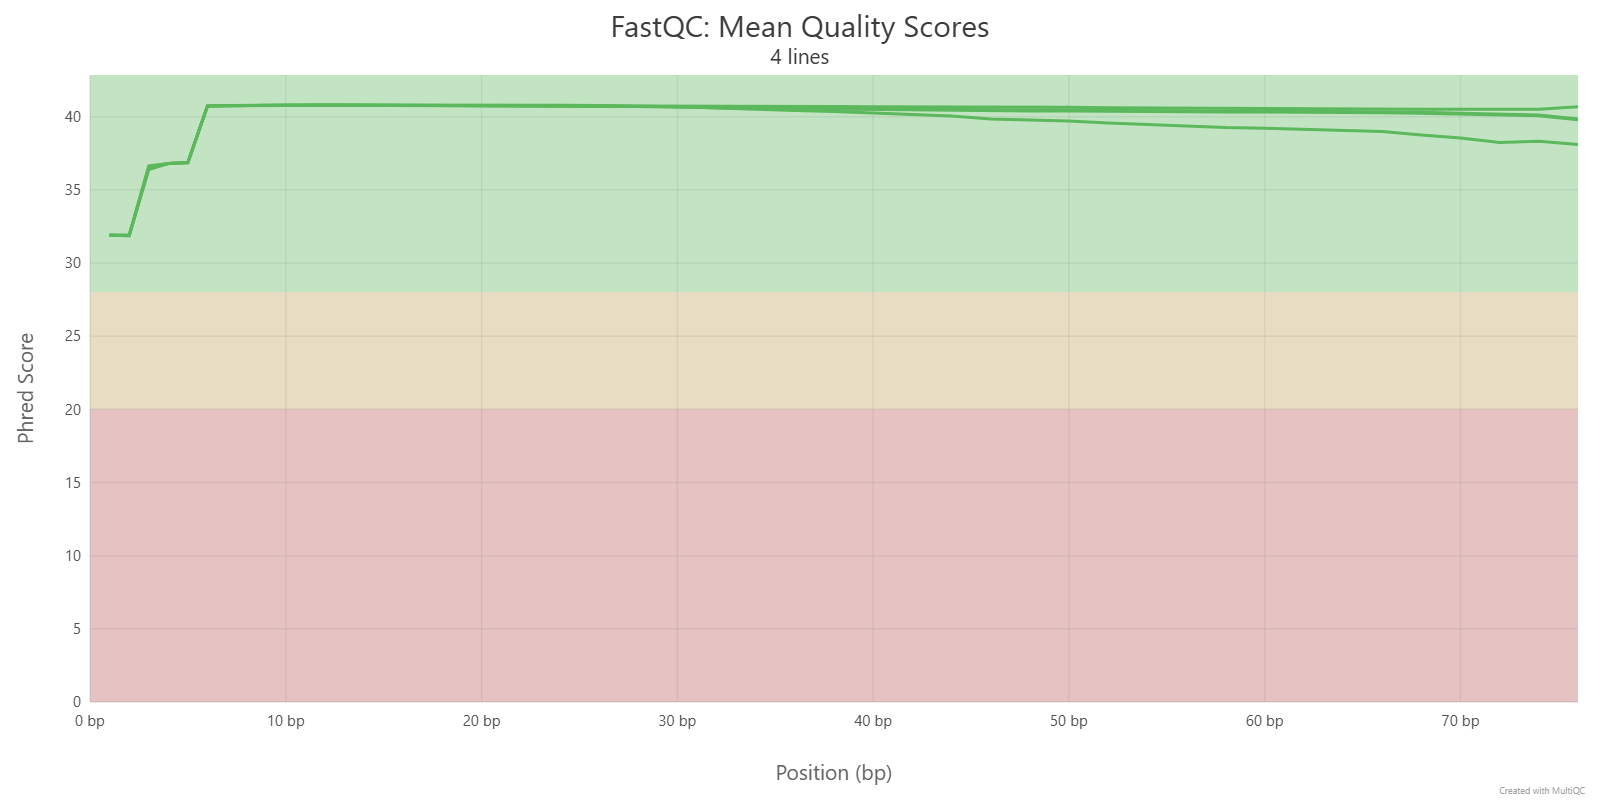

Качество данных сохранилось на высоком уровне. Как и исходные риды, риды после тримминга полностью находятся в зеленой зоне. В области position > 60 bp качетсво немного возрасло в результате применения "-- сut_front --cut_tail --cut_window_size 5 --cut_mean_quality 20".

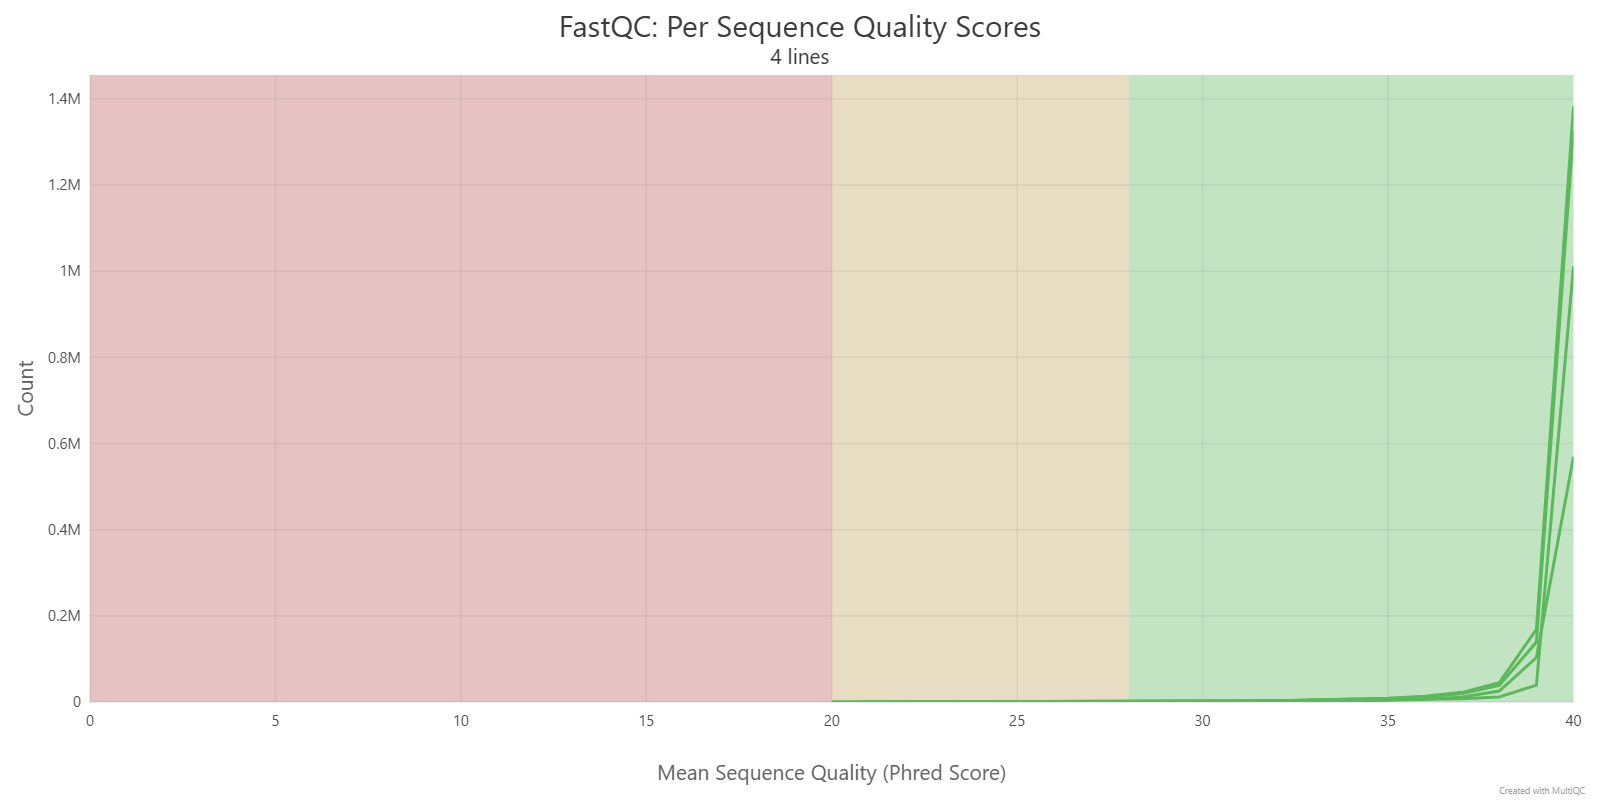

 Низкокачественные риды отфильтрованы (--average_qual 15). Распределение стало чище. Теперь среднее качество ридов не опускается ниже 20 Phred.

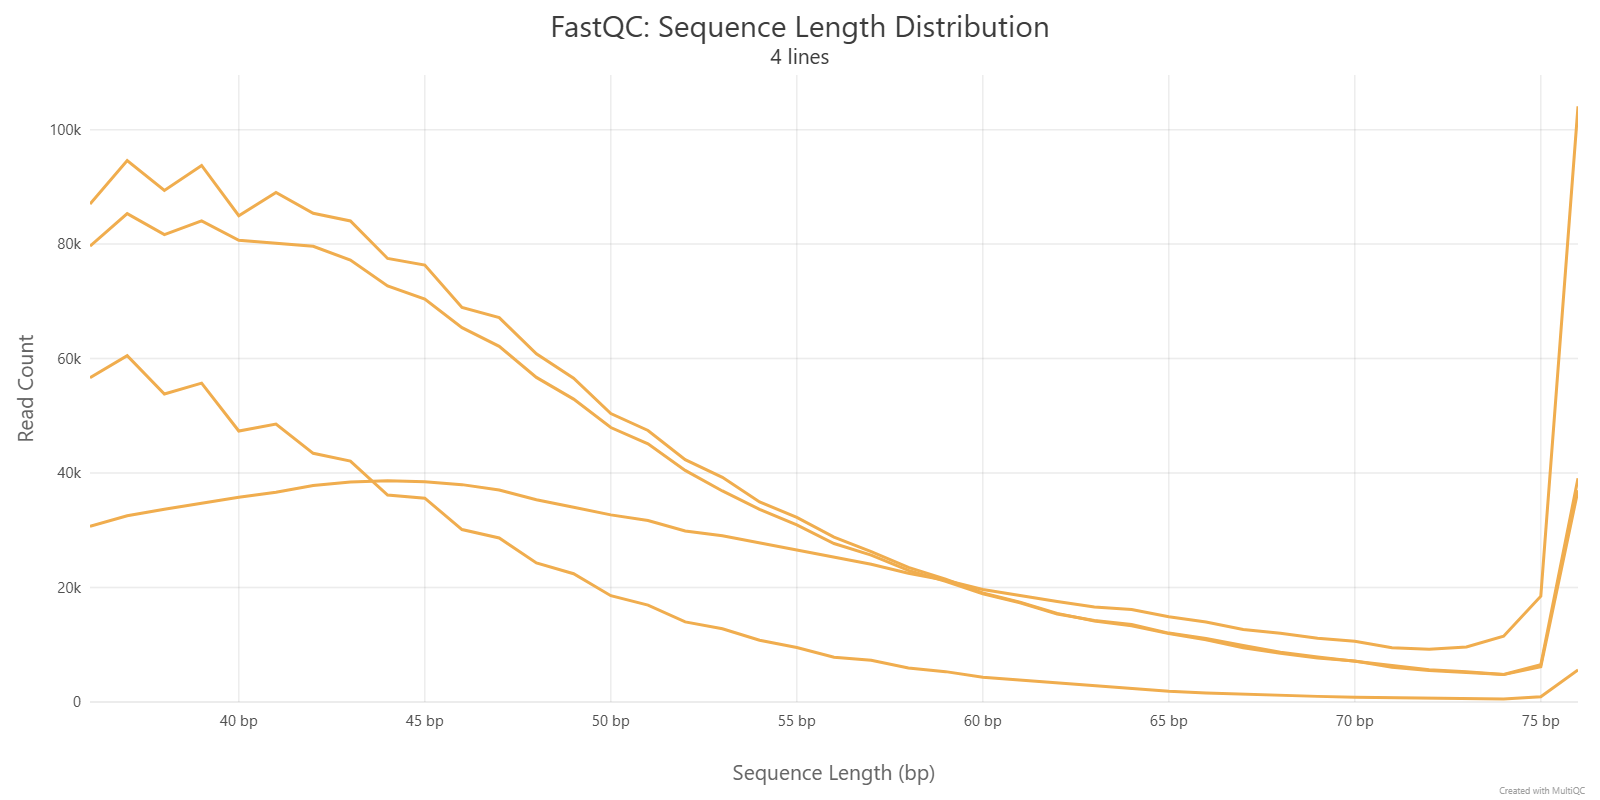

Риды короче 36 bp были удалены (--length_required 36)

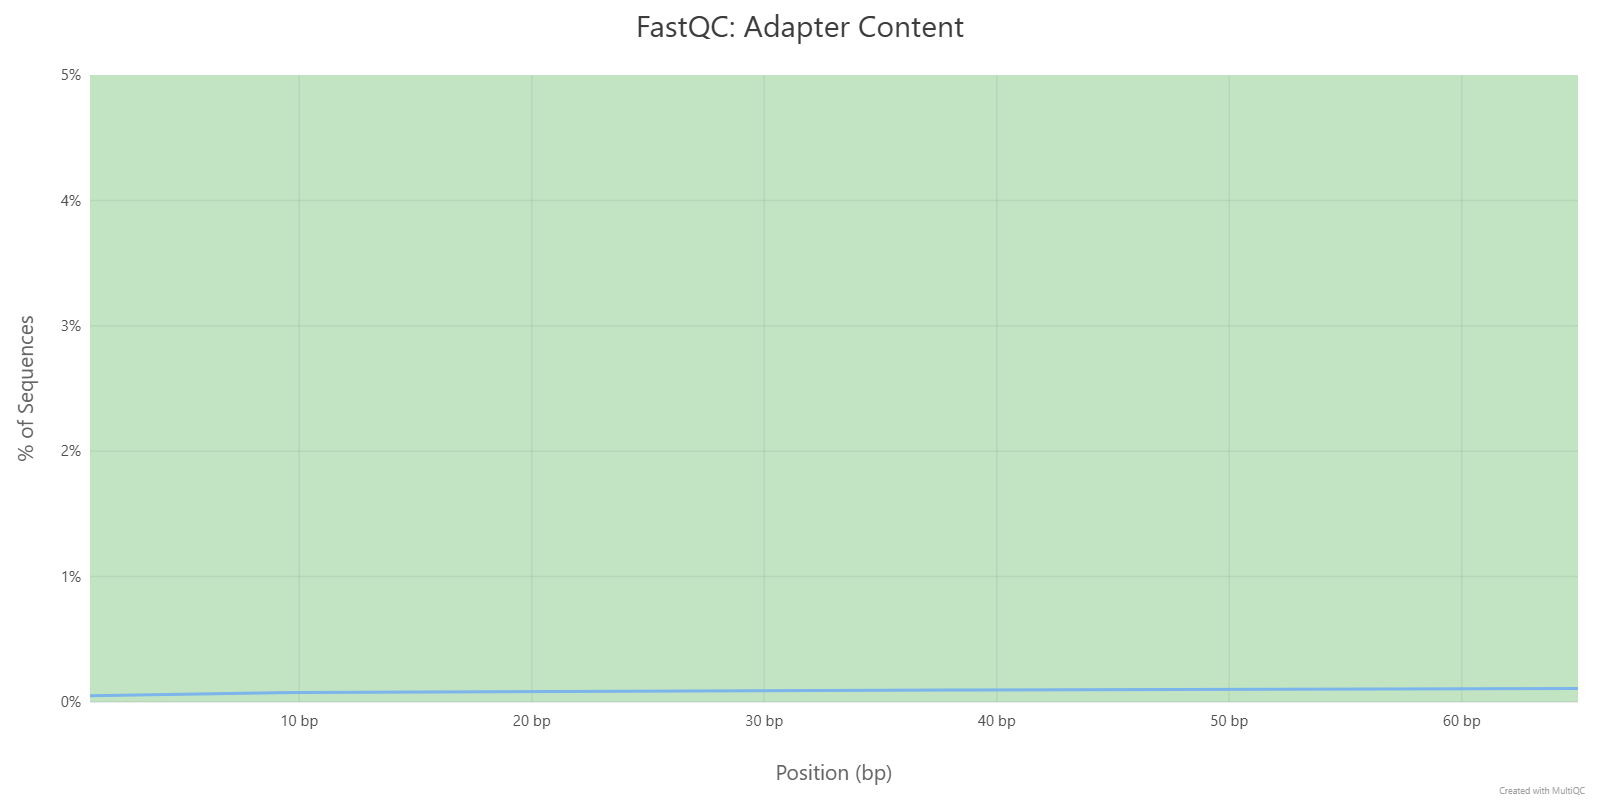

Адаптеры отсутствовали уже на исходных данных, так что видимых изменений при применении "--detect_adapter_for_pe" не наблюдается.

**Что еще изменилось:** Снизилась доля PCR-дупликатов: у самого проблемного образца (ERR14230594) — с 52,8% до 46,9%, у остальных — на 5–6% за счёт удаления избыточно представленных фрагментов. Нормализовался GC-состав у ERR14230594 (с 47% до 41%) благодаря удалению гомополимерных вставок (повторы AC/AC/TG). Общее число ридов закономерно сократилось (например, у ERR14230594 — с 1,0M до 0,7M). Overrepresented последовательности не исчезли полностью, но их доля уменьшилась.

**Выводы:** Качество исходных данных изначально было на высоком уровне. Тримминг позволил еще немного улучшить качество данных и устранить присутствующие проблемы: повысился профиль качества по позициям, снизилась доля дупликатов (особенно у проблемного образца), удалены короткие и низкокачественные риды.